# Рахимьянов Альберт, ЕТ-128, "Беггинг"

## Задание
1. Выполните классификацию набора данных из задания о Байесовской классификации с помощью бэггинга, варьируя количество участников ансамбля (от 50 до 100 с шагом 10).
2. Вычислите показатели качества классификации: аккуратность (accuracy), точность (precision), полнота (recall), F-мера. Выполните визуализацию полученных результатов в виде диаграмм. Нанесите на диаграммы соответствующие значения, полученные в заданиях о Байесовской классификации и деревьях решений.
3. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
- формулировка задания;
- гиперссылка на каталог репозитория с исходными текстами, набором данных и др. - сопутствующими материалами;
- рисунки с результатами визуализации;
- пояснения, раскрывающие смысл полученных результатов.


In [1]:
# Библиотеки
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Загрузка датасета "Рукописные цифры" (1797 объектов изначально) (10 классов)
np.random.seed(42)

X, y = load_digits(return_X_y=True)

X = X + np.random.normal(0, 0.5, X.shape)

print("Размерность данных:", X.shape, np.unique(y))

Размерность данных: (1797, 64) [0 1 2 3 4 5 6 7 8 9]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y # Фиксируем разбиение выборок: 80% обучающей и 20% тестовой
)

n_estimators_range = list(range(50, 110, 10)) # Варьируем количество участников ансамбля

metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

models = []

max_samples_values = [0.5, 1.0]  # Размер подвыборки
max_features_values = [0.5, 1.0] # Количество признаков

In [8]:
# Обучаем модели
all_results = {}

for max_s in max_samples_values:
    for max_f in max_features_values:
        param_key = f"samples={max_s}, features={max_f}"
        all_results[param_key] = {
            'n_estimators': [],
            'accuracy': [],
            'precision': [],
            'recall': [],
            'f1': []
        }

        for n in n_estimators_range:
            bagging_model = BaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=42),
                n_estimators=n,
                max_samples=max_s,
                max_features=max_f,
                random_state=42
            )

            bagging_model.fit(X_train, y_train)
            y_pred = bagging_model.predict(X_test)

            all_results[param_key]['n_estimators'].append(n)
            all_results[param_key]['accuracy'].append(accuracy_score(y_test, y_pred))
            all_results[param_key]['precision'].append(precision_score(y_test, y_pred, average='macro'))
            all_results[param_key]['recall'].append(recall_score(y_test, y_pred, average='macro'))
            all_results[param_key]['f1'].append(f1_score(y_test, y_pred, average='macro'))

In [9]:
for param_key, metrics in all_results.items():
    print(f"\n{param_key}:")
    print("=" * 60)
    print(f"{'n_estimators':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
    print("-" * 60)

    for i, n in enumerate(metrics['n_estimators']):
        print(f"{n:<15} "
              f"{metrics['accuracy'][i]:<12.4f} "
              f"{metrics['precision'][i]:<12.4f} "
              f"{metrics['recall'][i]:<12.4f} "
              f"{metrics['f1'][i]:<12.4f}")


samples=0.5, features=0.5:
n_estimators    Accuracy     Precision    Recall       F1          
------------------------------------------------------------
50              0.9361       0.9390       0.9355       0.9353      
60              0.9333       0.9368       0.9328       0.9326      
70              0.9306       0.9332       0.9300       0.9296      
80              0.9306       0.9337       0.9299       0.9294      
90              0.9306       0.9337       0.9299       0.9294      
100             0.9389       0.9411       0.9384       0.9383      

samples=0.5, features=1.0:
n_estimators    Accuracy     Precision    Recall       F1          
------------------------------------------------------------
50              0.9167       0.9183       0.9159       0.9155      
60              0.9083       0.9101       0.9075       0.9066      
70              0.9139       0.9157       0.9131       0.9123      
80              0.9167       0.9191       0.9159       0.9151      
90    

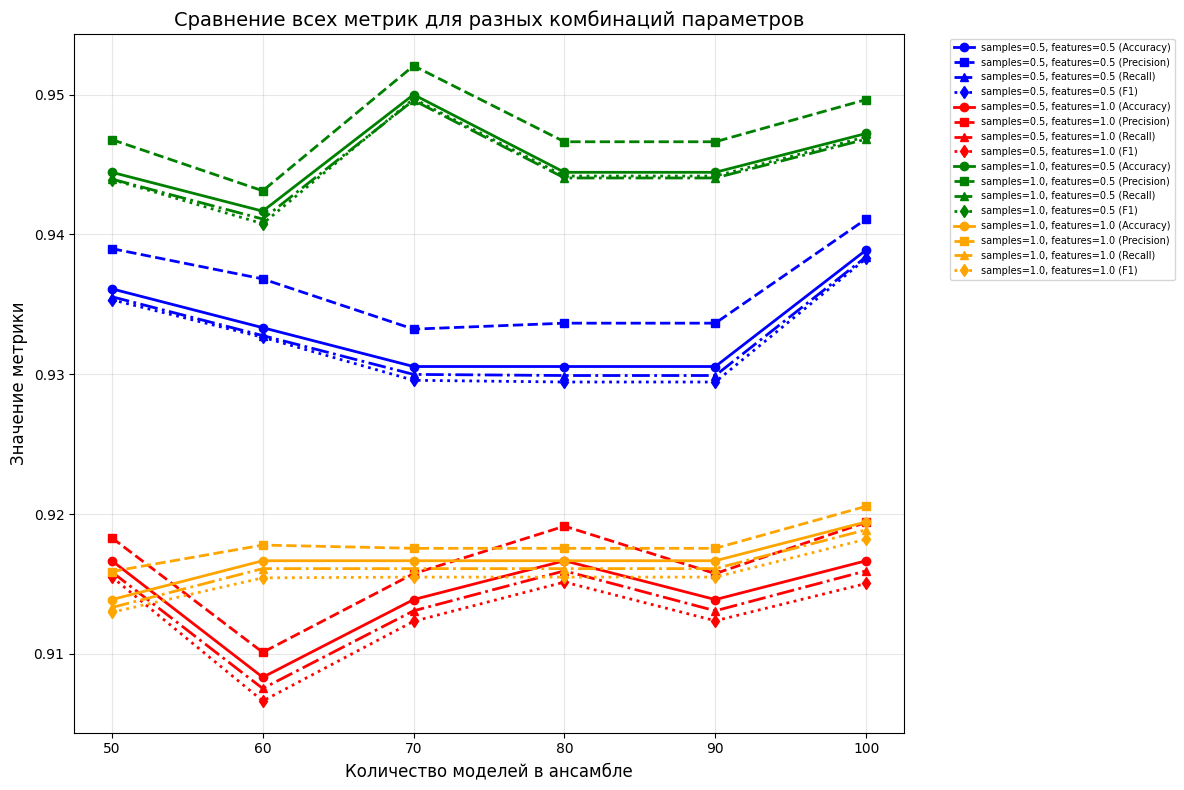

In [13]:
plt.figure(figsize=(12, 8))
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'd']
colors = ['blue', 'red', 'green', 'orange']

for idx, (param_key, metrics) in enumerate(all_results.items()):
    color = colors[idx % len(colors)]

    # Accuracy
    plt.plot(metrics['n_estimators'],
            metrics['accuracy'],
            linestyle='-',
            marker='o',
            color=color,
            linewidth=2,
            label=f'{param_key} (Accuracy)')

    # Precision
    plt.plot(metrics['n_estimators'],
            metrics['precision'],
            linestyle='--',
            marker='s',
            color=color,
            linewidth=2,
            label=f'{param_key} (Precision)')

    # Recall
    plt.plot(metrics['n_estimators'],
            metrics['recall'],
            linestyle='-.',
            marker='^',
            color=color,
            linewidth=2,
            label=f'{param_key} (Recall)')

    # F1
    plt.plot(metrics['n_estimators'],
            metrics['f1'],
            linestyle=':',
            marker='d',
            color=color,
            linewidth=2,
            label=f'{param_key} (F1)')

plt.xlabel("Количество моделей в ансамбле", fontsize=12)
plt.ylabel("Значение метрики", fontsize=12)
plt.title("Сравнение всех метрик для разных комбинаций параметров", fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(n_estimators_range)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

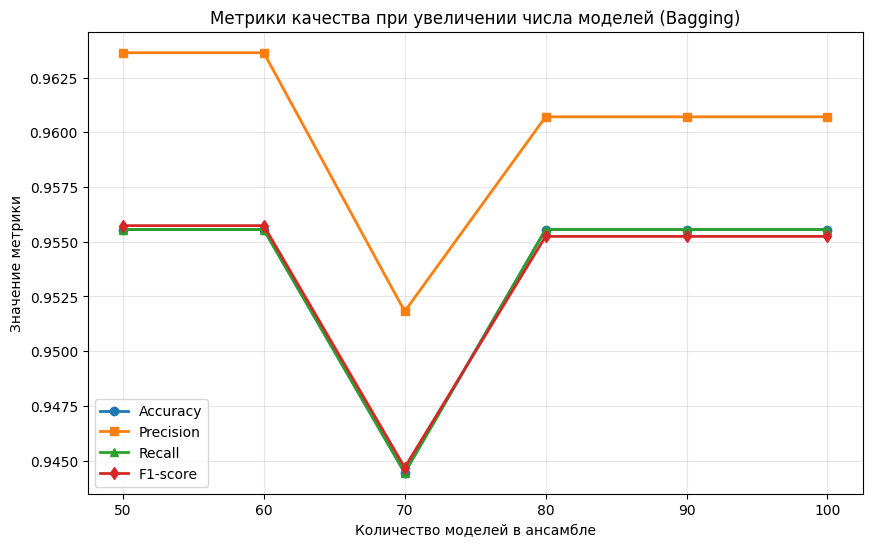

In [22]:
metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for n in n_estimators_range:

    bagging_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=n,
        max_samples=1.0,
        max_features=0.5,
        random_state=42
    )

    bagging_model.fit(X_train, y_train)
    models.append(bagging_model)

    y_pred = bagging_model.predict(X_test)

    metrics['accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['precision'].append(precision_score(y_test, y_pred, average='macro'))
    metrics['recall'].append(recall_score(y_test, y_pred, average='macro'))
    metrics['f1'].append(f1_score(y_test, y_pred, average='macro'))

plt.figure(figsize=(10, 6))

plt.plot(n_estimators_range, metrics['accuracy'], marker='o', linewidth=2, label='Accuracy')
plt.plot(n_estimators_range, metrics['precision'], marker='s', linewidth=2, label='Precision')
plt.plot(n_estimators_range, metrics['recall'], marker='^', linewidth=2, label='Recall')
plt.plot(n_estimators_range, metrics['f1'], marker='d', linewidth=2, label='F1-score')

plt.xlabel("Количество моделей в ансамбле")
plt.ylabel("Значение метрики")
plt.title("Метрики качества при увеличении числа моделей (Bagging)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(n_estimators_range)
# plt.ylim(0.8, 1.05)

plt.show()

In [20]:
# Варьируем размер обучающей выборки
train_ratios = list(range(50, 100, 5))

metrics_tree = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

metrics_bayes = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

for tr in train_ratios:

    ratio = tr / 100

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=ratio, random_state=42, stratify=y
    )

    # Дерево решений (Gini)
    tree_model = DecisionTreeClassifier(
        criterion="gini",
        random_state=42
    )

    tree_model.fit(X_train, y_train)
    y_pred_tree = tree_model.predict(X_test)

    metrics_tree["accuracy"].append(accuracy_score(y_test, y_pred_tree))
    metrics_tree["precision"].append(precision_score(y_test, y_pred_tree, average="macro"))
    metrics_tree["recall"].append(recall_score(y_test, y_pred_tree, average="macro"))
    metrics_tree["f1"].append(f1_score(y_test, y_pred_tree, average="macro"))


    # Байесовская классификация
    bayes_model = GaussianNB()
    bayes_model.fit(X_train, y_train)
    y_pred_bayes = bayes_model.predict(X_test)

    metrics_bayes["accuracy"].append(accuracy_score(y_test, y_pred_bayes))
    metrics_bayes["precision"].append(precision_score(y_test, y_pred_bayes, average="macro"))
    metrics_bayes["recall"].append(recall_score(y_test, y_pred_bayes, average="macro"))
    metrics_bayes["f1"].append(f1_score(y_test, y_pred_bayes, average="macro"))

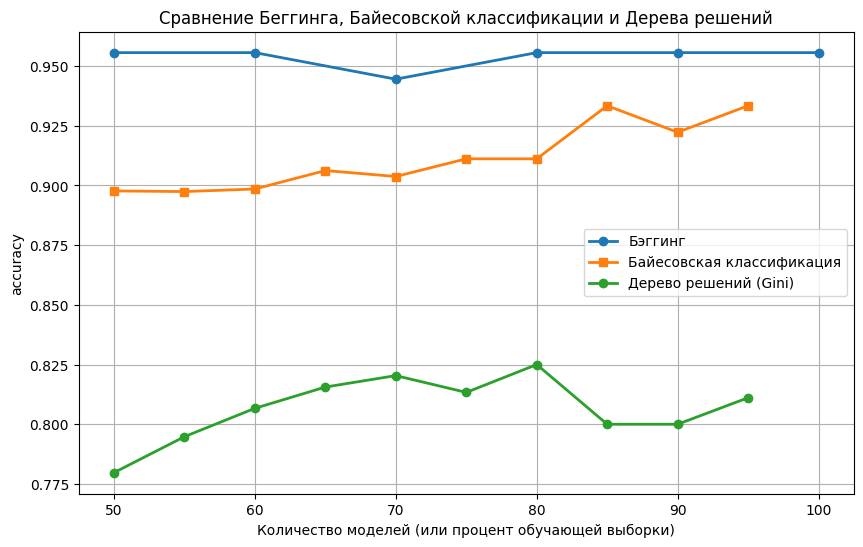

In [21]:
selected_metric = "accuracy"

tree_values = metrics_tree[selected_metric]
bayes_values = metrics_bayes[selected_metric]

plt.figure(figsize=(10, 6))

plt.plot(n_estimators_range, metrics[selected_metric], marker='o', linewidth=2, label='Бэггинг')
plt.plot(train_ratios, bayes_values, marker='s', linewidth=2, label="Байесовская классификация")
plt.plot(train_ratios, tree_values, marker='o', linewidth=2, label="Дерево решений (Gini)")

plt.xlabel("Количество моделей (или процент обучающей выборки)")
plt.ylabel(selected_metric)
plt.title("Сравнение Беггинга, Байесовской классификации и Дерева решений")
plt.legend()
plt.grid(True)
plt.show()